# Desafio 3: Datamind.

Este desafio requer ao menos 15 descobertas sustentada por dados, quanto mais útil para a "empresa", melhor.

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('Dataset_Data_Mining_Completo_5000.xlsx')

In [3]:
# Preparação com encadeamento (Feature Engineering)
df = df.assign(
    Data_Compra=pd.to_datetime(df['Data_Compra'], format='%d/%m/%Y'),
    Dia_da_Semana=lambda x: x['Data_Compra'].dt.day_name(),
    Cancelou=lambda x: x['Cancelou'].map({'Sim': 1, 'Não': 0}),
    Fraude=lambda x: x['Fraude'].map({'Sim': 1, 'Não': 0}),
    Cupom=lambda x: x['Cupom'].map({'Sim': 1, 'Não': 0}),
    Programa_Fidelidade=lambda x: x['Programa_Fidelidade'].map({'Sim': 1, 'Não': 0}),
    Faixa_Etaria=lambda x: pd.cut(x['Idade'], bins=[0, 25, 35, 45, 55, 100], labels=['Até 25', '26-35', '36-45', '46-55', '55+']),
    Faixa_Desconto=lambda x: pd.cut(x['Desconto_%'], bins=[0, 10, 20, 30, 50, 100], right=False)
)

### 1. Cliente: Idade e Renda dos 100 Maiores Clientes:

In [5]:
# [Célula 2]
df.groupby('ID_Cliente') \
  .agg(Faturamento=('Valor_Total', 'sum'), Idade=('Idade', 'first'), Renda=('Renda_Mensal', 'first')) \
  .nlargest(1000, 'Faturamento') \
  [['Idade', 'Renda']] \
  .mean() \
  .to_frame('Média dos Top 100 Clientes')

,Média dos Top 100 Clientes
Idade,44.687186
Renda,12041.914573


### 2. Cliente: Correlação entre Renda e Faturamento

In [6]:
df.groupby('ID_Cliente') \
  .agg(Renda=('Renda_Mensal', 'first'), Faturamento=('Valor_Total', 'sum')) \
  .corr() \
  .loc['Renda', ['Faturamento']] \
  .to_frame('Índice de Correlação')

,Índice de Correlação
Faturamento,-0.010605


### 3. Cliente: Preferência de Pagamento Regional

In [16]:
df.pivot_table(index='Regiao', columns='Forma_Pagamento', aggfunc='size', fill_value=0) \
  .apply(lambda x: (x / x.sum()) * 100, axis=1) \
  .round(2) \
  .style.format('{:.1f}%')

Forma_Pagamento,Boleto,Cartão,Pix
Regiao,,,
Centro-Oeste,33.9%,33.1%,33.1%
Nordeste,32.8%,35.5%,31.6%
Norte,32.0%,33.5%,34.5%
Sudeste,30.5%,35.2%,34.3%
Sul,33.4%,33.9%,32.6%


### 4. Cliente: Tempo de Casa versus Gasto

In [17]:
df.groupby('Tempo_Cliente_Anos')['Valor_Total'] \
  .mean() \
  .to_frame('Ticket Médio') \
  .round(2) \
  .style.bar(color='#d65f5f')

,Ticket Médio
Tempo_Cliente_Anos,
0,2598.090000
1,3083.160000
2,3055.770000
3,2978.050000
4,3387.280000
5,3286.000000
6,3275.150000
7,3123.360000
8,3015.600000


### 5. Cliente: Comportamento por Estado Civil

In [22]:
df.groupby('Estado_Civil') \
  .agg(Gasto_Medio=('Valor_Total', 'mean'), Itens=('Quantidade', 'mean'), Volume=('ID_Compra', 'count')) \
  .sort_values(by='Volume', ascending=False) \
  .round(2)

,Gasto_Medio,Itens,Volume
Estado_Civil,,,
Casado,3149.90,2.53,1731
Solteiro,3192.62,2.47,1730
Divorciado,3332.19,2.51,1539


### 6. Risco: Perfil das Compras Fraudulentas

In [7]:
df.groupby('Fraude') \
  .agg(
      Idade_Media=('Idade', 'mean'),
      Renda_Media=('Renda_Mensal', 'mean'),
      Ticket_Medio=('Valor_Total', 'mean'),
      Genero_Frequente=('Sexo', lambda x: x.mode()[0]),
      Mes_Frequente=('Mes', lambda x: x.mode()[0])
  ).rename(index={1: 'Fraude Confimada', 0: 'Compra Legítima'})

,Idade_Media,Renda_Media,Ticket_Medio,Genero_Frequente,Mes_Frequente
Fraude,,,,,
Compra Legítima,44.241667,12002.795325,3083.15935,F,November
Fraude Confimada,44.412500,12211.650000,11685.01250,M,November


### 7. Risco: Retenção do Programa de Fidelidade

In [8]:
(df.groupby('Programa_Fidelidade')['Cancelou'].mean() * 100) \
  .to_frame('Taxa de Cancelamento (%)') \
  .rename(index={1: 'No Programa', 0: 'Fora do Programa'}) \
  .round(2)

,Taxa de Cancelamento (%)
Programa_Fidelidade,
Fora do Programa,11.32
No Programa,9.63


### 8. Risco: Vulnerabilidade de Pagamento por Canal

In [9]:
(df.groupby(['Canal', 'Forma_Pagamento'])['Fraude'].mean() * 100) \
  .sort_values(ascending=False) \
  .to_frame('% de Fraudes') \
  .round(2) \
  .head(5)

% de Fraudes
Canal Forma_Pagamento              
App   Pix                      5.58
Site  Pix                      3.61
Loja  Pix                      3.20
      Cartão                   0.83
App   Boleto                   0.38

### 9. Risco: Tentativas de fraude por região

In [33]:
(df.groupby('Regiao')['Fraude'].mean() * 100) \
  .sort_values(ascending=False) \
  .to_frame('Risco de Fraude (%)') \
  .round(2)

,Risco de Fraude (%)
Regiao,
Norte,2.01
Centro-Oeste,1.85
Sul,1.77
Nordeste,1.50
Sudeste,1.06


### 10. Risco: Métodos com Maior Devolução/Cancelamento

In [34]:
(df.groupby('Forma_Pagamento')['Cancelou'].mean() * 100) \
  .sort_values(ascending=False) \
  .to_frame('Taxa de Cancelamento (%)') \
  .round(2)

,Taxa de Cancelamento (%)
Forma_Pagamento,
Cartão,11.27
Pix,10.08
Boleto,9.67


### 11. Risco: Categorias com Maior Devolução/Cancelamento

In [10]:
(df.groupby('Categoria')['Cancelou'].mean() * 100) \
  .sort_values(ascending=False) \
  .to_frame('Taxa de Cancelamento (%)') \
  .round(2)

,Taxa de Cancelamento (%)
Categoria,
Redes,11.15
Informática,10.86
Armazenamento,10.62
Telefonia,9.65
Móveis,9.35
Wearables,8.25


### 12. Vendas: Performance e Ticket por Canal

In [11]:
df.groupby('Canal') \
  .agg(Volume=('ID_Compra', 'count'), Ticket_Medio=('Valor_Total', 'mean'), Receita_Total=('Valor_Total', 'sum')) \
  .sort_values(by='Receita_Total', ascending=False) \
  .style.format({'Ticket_Medio': 'R$ {:.2f}', 'Receita_Total': 'R$ {:.2f}'})

,Volume,Ticket_Medio,Receita_Total
Canal,,,
App,1693,R$ 3321.71,R$ 5623656.00
Loja,1792,R$ 3115.05,R$ 5582171.00
Site,1515,R$ 3233.08,R$ 4898118.00


### 13. Vendas: Impacto Real dos Cupons de Desconto

In [12]:
df.groupby('Cupom') \
  .agg(Ticket_Medio=('Valor_Total', 'mean'), Itens_Media=('Quantidade', 'mean'), Avaliacao=('Avaliacao', 'mean')) \
  .rename(index={1: 'Com Cupom', 0: 'Sem Cupom'}) \
  .round(2)

,Ticket_Medio,Itens_Media,Avaliacao
Cupom,,,
Sem Cupom,3350.9,2.50,3.93
Com Cupom,3134.7,2.51,3.99


### 14. Vendas: Faturamento por Faixa Etária

In [13]:
df.groupby('Faixa_Etaria', observed=True)['Valor_Total'] \
  .sum() \
  .sort_values(ascending=False) \
  .to_frame('Faturamento Total') \
  .style.format('R$ {:.2f}')

,Faturamento Total
Faixa_Etaria,
55+,R$ 4572490.00
26-35,R$ 3143179.00
36-45,R$ 3072641.00
46-55,R$ 2955936.50
Até 25,R$ 2359698.50


### 15. Vendas: Sazonalidade por mês

In [23]:
df.groupby('Mes')['Valor_Total'] \
  .agg(['count', 'sum', 'mean']) \
  .rename(columns={'count': 'Volume', 'sum': 'Faturamento', 'mean': 'Ticket Medio'}) \
  .sort_values(by='Faturamento', ascending=False)

,Volume,Faturamento,Ticket Medio
Mes,,,
November,457,1487625.5,3255.198031
February,422,1409923.5,3341.050948
April,434,1404889.5,3237.072581
March,421,1379141.0,3275.869359
October,413,1376756.5,3333.550847
June,417,1363479.5,3269.735012
August,432,1339563.0,3100.840278
December,398,1337900.5,3361.559045
July,391,1318731.0,3372.713555


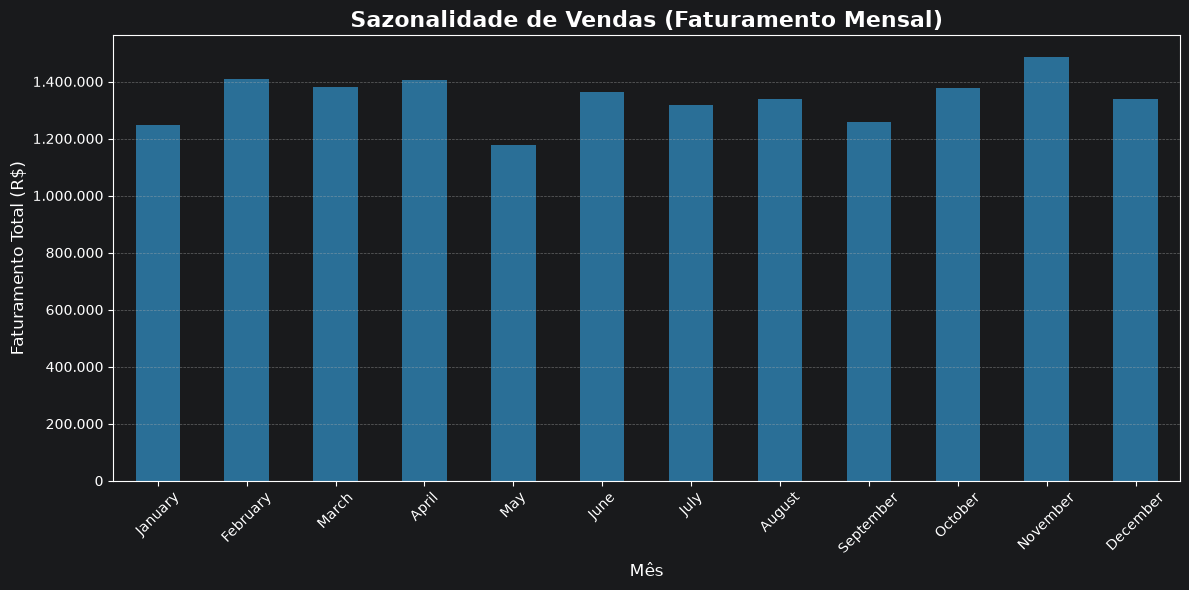

In [26]:
import matplotlib.pyplot as plt

ordem_meses = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# 2. Fazendo a consulta e reindexando cronologicamente
resultado = df.groupby('Mes')['Valor_Total'] \
  .agg(['count', 'sum', 'mean']) \
  .rename(columns={'count': 'Volume', 'sum': 'Faturamento', 'mean': 'Ticket Medio'}) \
  .reindex(ordem_meses)

# 3. Gerando o Gráfico de Barras
plt.figure(figsize=(12, 6))
ax = resultado['Faturamento'].plot(kind='bar', color='#2a6f97')

# 4. Ajustes visuais para a sua apresentação
plt.title('Sazonalidade de Vendas (Faturamento Mensal)', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(rotation=45) # Inclina os nomes dos meses

# Formatação do eixo Y (Deixa o valor em formato legível em vez de notação científica)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', '.')))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Exibe o gráfico na célula do Jupyter
plt.show()

### 16. Vendas: Faturamento por cidade

In [28]:
df.groupby('Cidade')['Valor_Total'] \
  .sum() \
  .sort_values(ascending=False) \
  .to_frame('Faturamento Total') \
  .style.format('R$ {:,.2f}'.format)

,Faturamento Total
Cidade,
Manaus,"R$ 2,940,892.00"
São Paulo,"R$ 2,207,590.00"
Brasília,"R$ 1,970,282.00"
Recife,"R$ 1,877,519.00"
Curitiba,"R$ 1,832,827.50"
Fortaleza,"R$ 1,812,881.00"
Rio de Janeiro,"R$ 1,763,948.00"
Belém,"R$ 1,698,005.50"


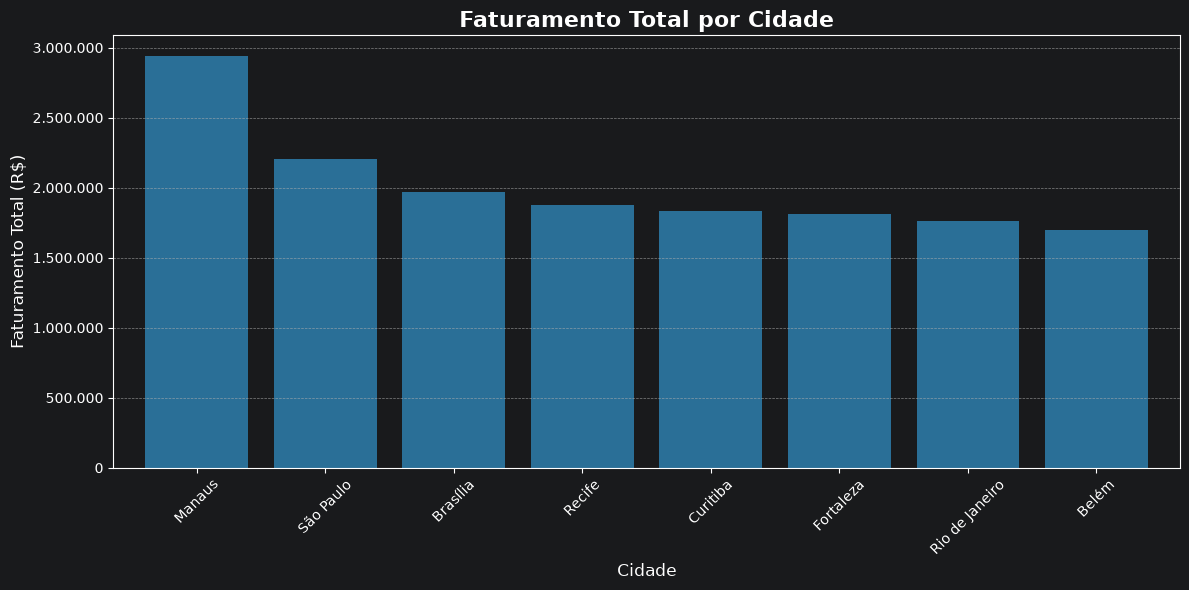

In [32]:
faturamento_cidade = df.groupby('Cidade')['Valor_Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

ax = faturamento_cidade.plot(kind='bar', color='#2a6f97', width=0.8)

# 4. Ajustes de Títulos e Eixos
plt.title('Faturamento Total por Cidade', fontsize=16, fontweight='bold')
plt.xlabel('Cidade', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', '.')))

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

### 17. Produto: Avaliação baseada no Percentual de Desconto

In [15]:
df.groupby('Faixa_Desconto', observed=True)['Avaliacao'] \
  .mean() \
  .to_frame('Avaliação Média') \
  .round(2)

,Avaliação Média
Faixa_Desconto,
"[0, 10)",3.96
"[10, 20)",3.98
"[20, 30)",3.92


### 18. Produto: Top 3 Produtos (Clientes Novatos vs Veteranos)

In [ ]:
df.assign(
    Perfil=lambda x: pd.cut(x['Tempo_Cliente_Anos'], bins=[-1, 1, 3, 100], labels=['Novato', 'Intermediário', 'Veterano'])
).query("Perfil in ['Novato', 'Veterano']") \
 .groupby(['Perfil', 'Produto'], observed=True) \
 .size() \
 .reset_index(name='Volume') \
 .sort_values(['Perfil', 'Volume'], ascending=[True, False]) \
 .groupby('Perfil', observed=True) \
 .head(3) \
 .set_index(['Perfil', 'Produto'])